In [1]:
%autosave 60
from IPython.display import display, HTML
import s3fit
display(HTML("<style>.container { width:100% !important; }</style>"))
import os
os.environ["OPENBLAS_NUM_THREADS"] = "64"

from copy import deepcopy as copy
import matplotlib.pyplot as plt

import warnings

import astropy.units as u
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import pathlib
import matplotlib as mpl
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from collections import defaultdict
import re
import scipy
from astropy.io import fits as asfits
from s3fit import FitFrame

mpl.rcParams['font.family'] = 'serif'


import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

s3fit_results_path = pathlib.Path('./s3fit_results/')
s3fit_results_path.mkdir(parents=True, exist_ok=True)

figs_path=pathlib.Path('./figs_spectrum_fits/')
figs_path.mkdir(parents=True, exist_ok=True)

DJAv4Catalog.to_dataframe()


Autosaving every 60 seconds


537


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{}


In [ ]:
all_formed_stellar_masses=np.array([])
mass_weight_ages=np.array([])
mass_weight_metallicities=np.array([])
alpha_nlr=np.array([])
alpha_blr=np.array([])
beta_nlr=np.array([])
beta_blr=np.array([])


for s3fit_result in tqdm(s3fit_results_path.glob('*.pkl.gz')):
    FF=FitFrame()
    FF.reload_from_file(s3fit_result)
    mod='el'
    output_el_spec_c=FF.model_dict[mod]['spec_mod'].extract_results(FF,'spec',False,True)
    alpha_nlr=np.append(alpha_nlr,output_el_spec_c['NLR']['values']['Ha'])
    beta_nlr=np.append(beta_nlr,output_el_spec_c['NLR']['values']['Hb'])
    alpha_blr=np.append(alpha_blr,output_el_spec_c['outflow_1']['values']['Ha'])
    beta_blr=np.append(beta_blr,output_el_spec_c['outflow_1']['values']['Hb'])



In [2]:
# np.savez('./s3fit_results.npz',
#          alpha_nlr=alpha_nlr,
#          alpha_blr=alpha_blr,
#          beta_nlr=beta_nlr,
#          beta_blr=beta_blr,
#          all_formed_stellar_masses=all_formed_stellar_masses,
#             mass_weight_ages=mass_weight_ages,
#             mass_weight_metallicities=mass_weight_metallicities

#          )


alpha_nlr,alpha_blr,beta_nlr,beta_blr,all_formed_stellar_masses,mass_weight_ages,mass_weight_metallicities=np.load('./s3fit_results.npz').values()

In [41]:
alpha_nlr.shape

(170,)

In [3]:
ymin=np.nanmin((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr))
ymax=np.nanmax((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr))
xmin=np.nanmin(alpha_nlr/beta_nlr)
xmax=np.nanmax(alpha_nlr/beta_nlr)

Text(0.5, 1.0, 'Balmer Decrement with BLR')

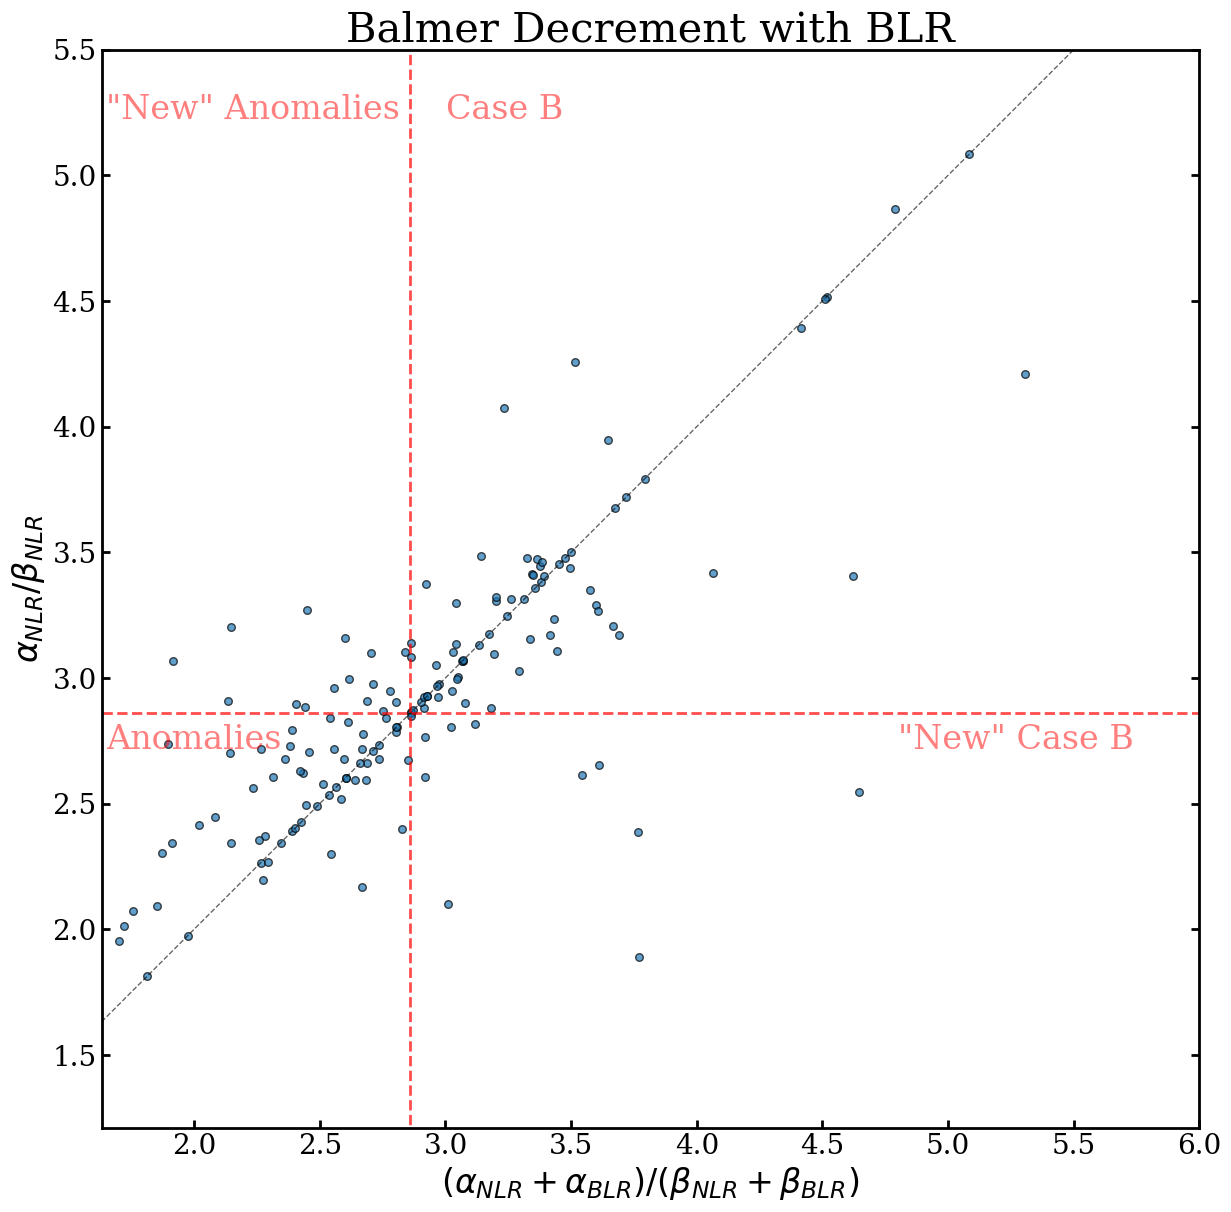

In [ ]:
fig, ax=plt.subplots(figsize=(25,14))
ax.scatter((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr),alpha_nlr/beta_nlr,s=30,alpha=0.7,edgecolors='black',lw=1)
ax.set_ylabel(r'$\alpha_{NLR}/\beta_{NLR}$',fontsize=24)
ax.set_xlabel(r'$(\alpha_{NLR}+\alpha_{BLR})/(\beta_{NLR}+\beta_{BLR})$',fontsize=24)
ax.vlines(x=2.86,ymin=0,ymax=100, colors='red', linestyles='dashed', lw=2, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_ylim(ymin*0.9, 5.5)
ax.hlines(y=2.86,xmin=0,xmax=10, colors='red', linestyles='dashed', lw=2, alpha=0.7)
ax.set_xlim(xmin*0.9, 6)
ax.plot([xmin*0.9,7],[xmin*0.9,7], color='black', lw=1,alpha=0.6,ls='--', zorder=1)


ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.set_aspect('equal', adjustable='box')


ax.text(2.86*1.05, 5.5*0.95, 'Case B', fontsize=24, color='red', alpha=0.5)
ax.text(6*0.8, 2.86*0.95, '"New" Case B', fontsize=24, color='red', alpha=0.5)
ax.text(1.65,5.5*0.95, '"New" Anomalies', fontsize=24, color='red', alpha=0.5)
ax.text(1.65,2.86*0.95, 'Anomalies', fontsize=24, color='red', alpha=0.5)

ax.set_title("Balmer Decrement with BLR",fontsize=30)

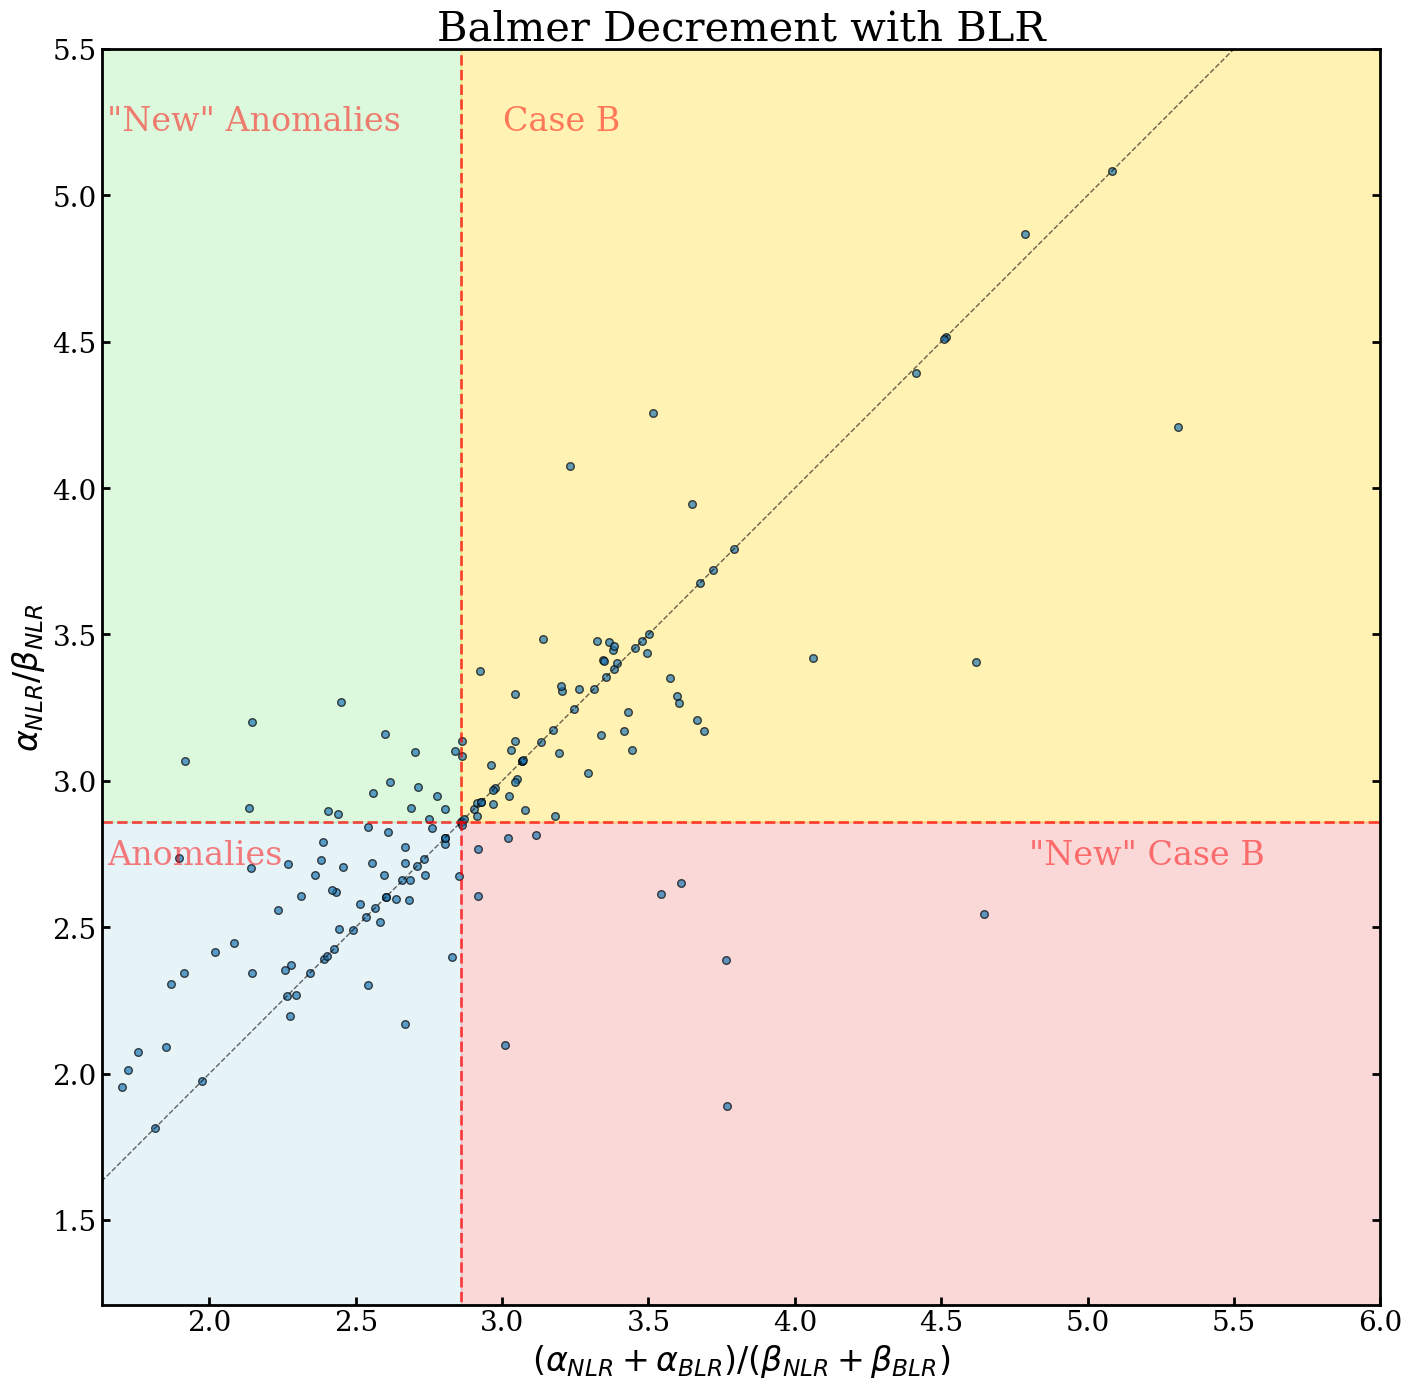

In [ ]:

# 定义分割线
X_split = 2.86
Y_split = 2.86

# 定义轴范围
X_min = xmin * 0.9
X_max = 6
Y_min = ymin * 0.9
Y_max = 5.5

fig, ax=plt.subplots(figsize=(25,14))

# === 关键改动：添加四个区域的填充 (fill_between) ===
# 为了清晰，我们使用四个不同的颜色和 label，并设置 zorder=0 确保它们在最底层
ZORDER_BACKGROUND = 0

# 1. 左下角 (L-B): X < 2.86 且 Y < 2.86
ax.fill_between([X_min, X_split], Y_min, Y_split,
                color='lightblue', alpha=0.3, zorder=ZORDER_BACKGROUND, label='Anomalies')

# 2. 右下角 (R-B): X > 2.86 且 Y < 2.86
ax.fill_between([X_split, X_max], Y_min, Y_split,
                color='lightcoral', alpha=0.3, zorder=ZORDER_BACKGROUND, label='"New" Anomalies')

# 3. 左上角 (L-T): X < 2.86 且 Y > 2.86
ax.fill_between([X_min, X_split], Y_split, Y_max,
                color='lightgreen', alpha=0.3, zorder=ZORDER_BACKGROUND, label='"New" Case B')

# 4. 右上角 (R-T): X > 2.86 且 Y > 2.86
ax.fill_between([X_split, X_max], Y_split, Y_max,
                color='gold', alpha=0.3, zorder=ZORDER_BACKGROUND, label='Case B')
# ====================================================


# 散点图
ax.scatter((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr),alpha_nlr/beta_nlr,s=30,alpha=0.7,edgecolors='black',lw=1)

# 分割线
ax.vlines(x=X_split,ymin=0,ymax=100, colors='red', linestyles='dashed', lw=2, alpha=0.7, zorder=2) # zorder=2 确保线在背景和散点图下
ax.hlines(y=Y_split,xmin=0,xmax=10, colors='red', linestyles='dashed', lw=2, alpha=0.7, zorder=2) # zorder=2 确保线在背景和散点图下

# 对角线
ax.plot([X_min,7],[X_min,7], color='black', lw=1,alpha=0.6,ls='--', zorder=1)


# 轴和刻度设置
ax.set_ylabel(r'$\alpha_{NLR}/\beta_{NLR}$',fontsize=24)
ax.set_xlabel(r'$(\alpha_{NLR}+\alpha_{BLR})/(\beta_{NLR}+\beta_{BLR})$',fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=30)

# 设置轴限制 (使用定义的范围变量)
ax.set_ylim(Y_min, Y_max)
ax.set_xlim(X_min, X_max)


# 轴样式
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')

# 保证等比例
ax.set_aspect('equal', adjustable='box')


# 文本标注 (调整位置以适应背景颜色和避免重叠)
# 注意：这些文本标签与填充区域的颜色/标签是对应的
ax.text(2.86*1.05, 5.5*0.95, 'Case B', fontsize=24, color='red', alpha=0.5)
ax.text(6*0.8, 2.86*0.95, '"New" Case B', fontsize=24, color='red', alpha=0.5)
ax.text(1.65,5.5*0.95, '"New" Anomalies', fontsize=24, color='red', alpha=0.5)
ax.text(1.65,2.86*0.95, 'Anomalies', fontsize=24, color='red', alpha=0.5)

ax.set_title("Balmer Decrement with BLR",fontsize=30)
plt.savefig('./balmer_decrement_with_blr_filled_colors.pdf')
plt.tight_layout()
plt.show()

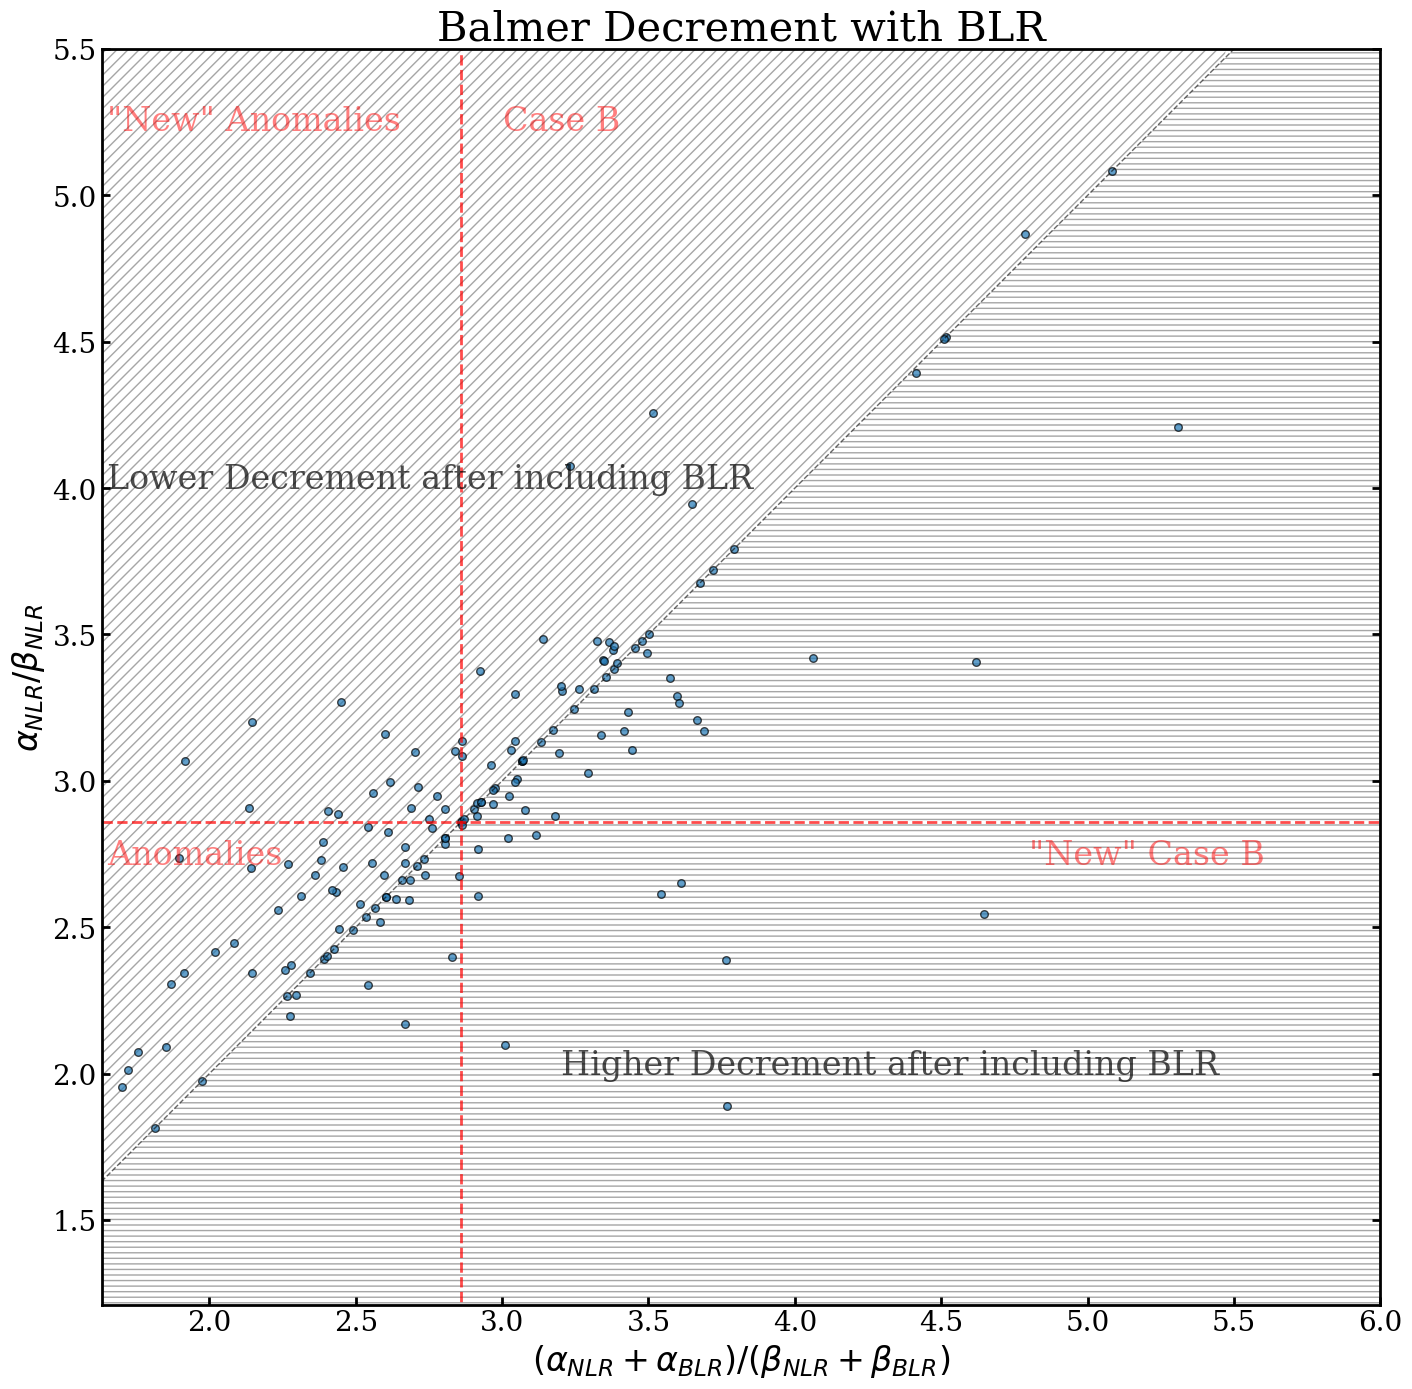

In [23]:

# 定义轴范围
X_min = xmin * 0.9
X_max = 6
Y_min = ymin * 0.9
Y_max = 5.5

# 定义对角线范围 (使用 ax.plot 相同的范围)
diag_start = X_min
diag_end = 7
X_diag = np.linspace(X_min, X_max, 100) # 生成用于 fill_between 的 X 坐标
Y_diag = X_diag # 对角线方程：Y = X


fig, ax=plt.subplots(figsize=(25,14))

# === 关键改动：添加阴影填充 ===
ZORDER_HATCH = 0.5 # 放在背景和数据之间

# 1. 对角线上部区域填充 (Y > X)
# X 范围: 从 X_min 到 X_max
# Y1: 对角线 (Y_diag)
# Y2: 轴的上限 (Y_max)
ax.fill_between(X_diag, Y_diag, Y_max,
                where=(Y_diag < Y_max), # 确保只在有效范围内填充
                color='none', # 不填充颜色
                edgecolor='gray',
                hatch='///', # 密集的对角线阴影
                linewidth=0,
                alpha=0.7,
                zorder=ZORDER_HATCH,
                label='Y > X Hatch')

# 2. 对角线下部区域填充 (Y < X)
# X 范围: 从 X_min 到 X_max
# Y1: 轴的下限 (Y_min)
# Y2: 对角线 (Y_diag)
ax.fill_between(X_diag, Y_min, Y_diag,
                where=(Y_diag > Y_min), # 确保只在有效范围内填充
                color='none',
                edgecolor='gray',
                hatch='---', # 水平线阴影
                linewidth=0,
                alpha=0.7,
                zorder=ZORDER_HATCH,
                label='Y < X Hatch')
# ==================================


# 散点图
ax.scatter((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr),alpha_nlr/beta_nlr,s=30,alpha=0.7,edgecolors='black',lw=1)

# 分割线
ax.vlines(x=2.86,ymin=0,ymax=100, colors='red', linestyles='dashed', lw=2, alpha=0.7)
ax.hlines(y=2.86,xmin=0,xmax=10, colors='red', linestyles='dashed', lw=2, alpha=0.7)

# 对角线 (保留原始的 plot)
ax.plot([diag_start,diag_end],[diag_start,diag_end], color='black', lw=1,alpha=0.6,ls='--', zorder=1)


# 轴和刻度设置
ax.set_ylabel(r'$\alpha_{NLR}/\beta_{NLR}$',fontsize=24)
ax.set_xlabel(r'$(\alpha_{NLR}+\alpha_{BLR})/(\beta_{NLR}+\beta_{BLR})$',fontsize=24)
ax.tick_params(axis='both', which='major', labelsize=30)

# 设置轴限制 (使用定义的范围变量)
ax.set_ylim(Y_min, Y_max)
ax.set_xlim(X_min, X_max)

# 轴样式
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')

# 保证等比例
ax.set_aspect('equal', adjustable='box')


# 文本标注
ax.text(2.86*1.05, 5.5*0.95, 'Case B', fontsize=24, color='red', alpha=0.5)
ax.text(6*0.8, 2.86*0.95, '"New" Case B', fontsize=24, color='red', alpha=0.5)
ax.text(1.65,5.5*0.95, '"New" Anomalies', fontsize=24, color='red', alpha=0.5)
ax.text(1.65,2.86*0.95, 'Anomalies', fontsize=24, color='red', alpha=0.5)

ax.text(1.65,4, 'Lower Decrement after including BLR', fontsize=24, color='black', alpha=0.7)
ax.text(3.2,2.0, 'Higher Decrement after including BLR', fontsize=24, color='black', alpha=0.7)

ax.set_title("Balmer Decrement with BLR",fontsize=30)

plt.savefig('./balmer_decrement_with_blr_hatched.pdf')
plt.tight_layout()
plt.show()

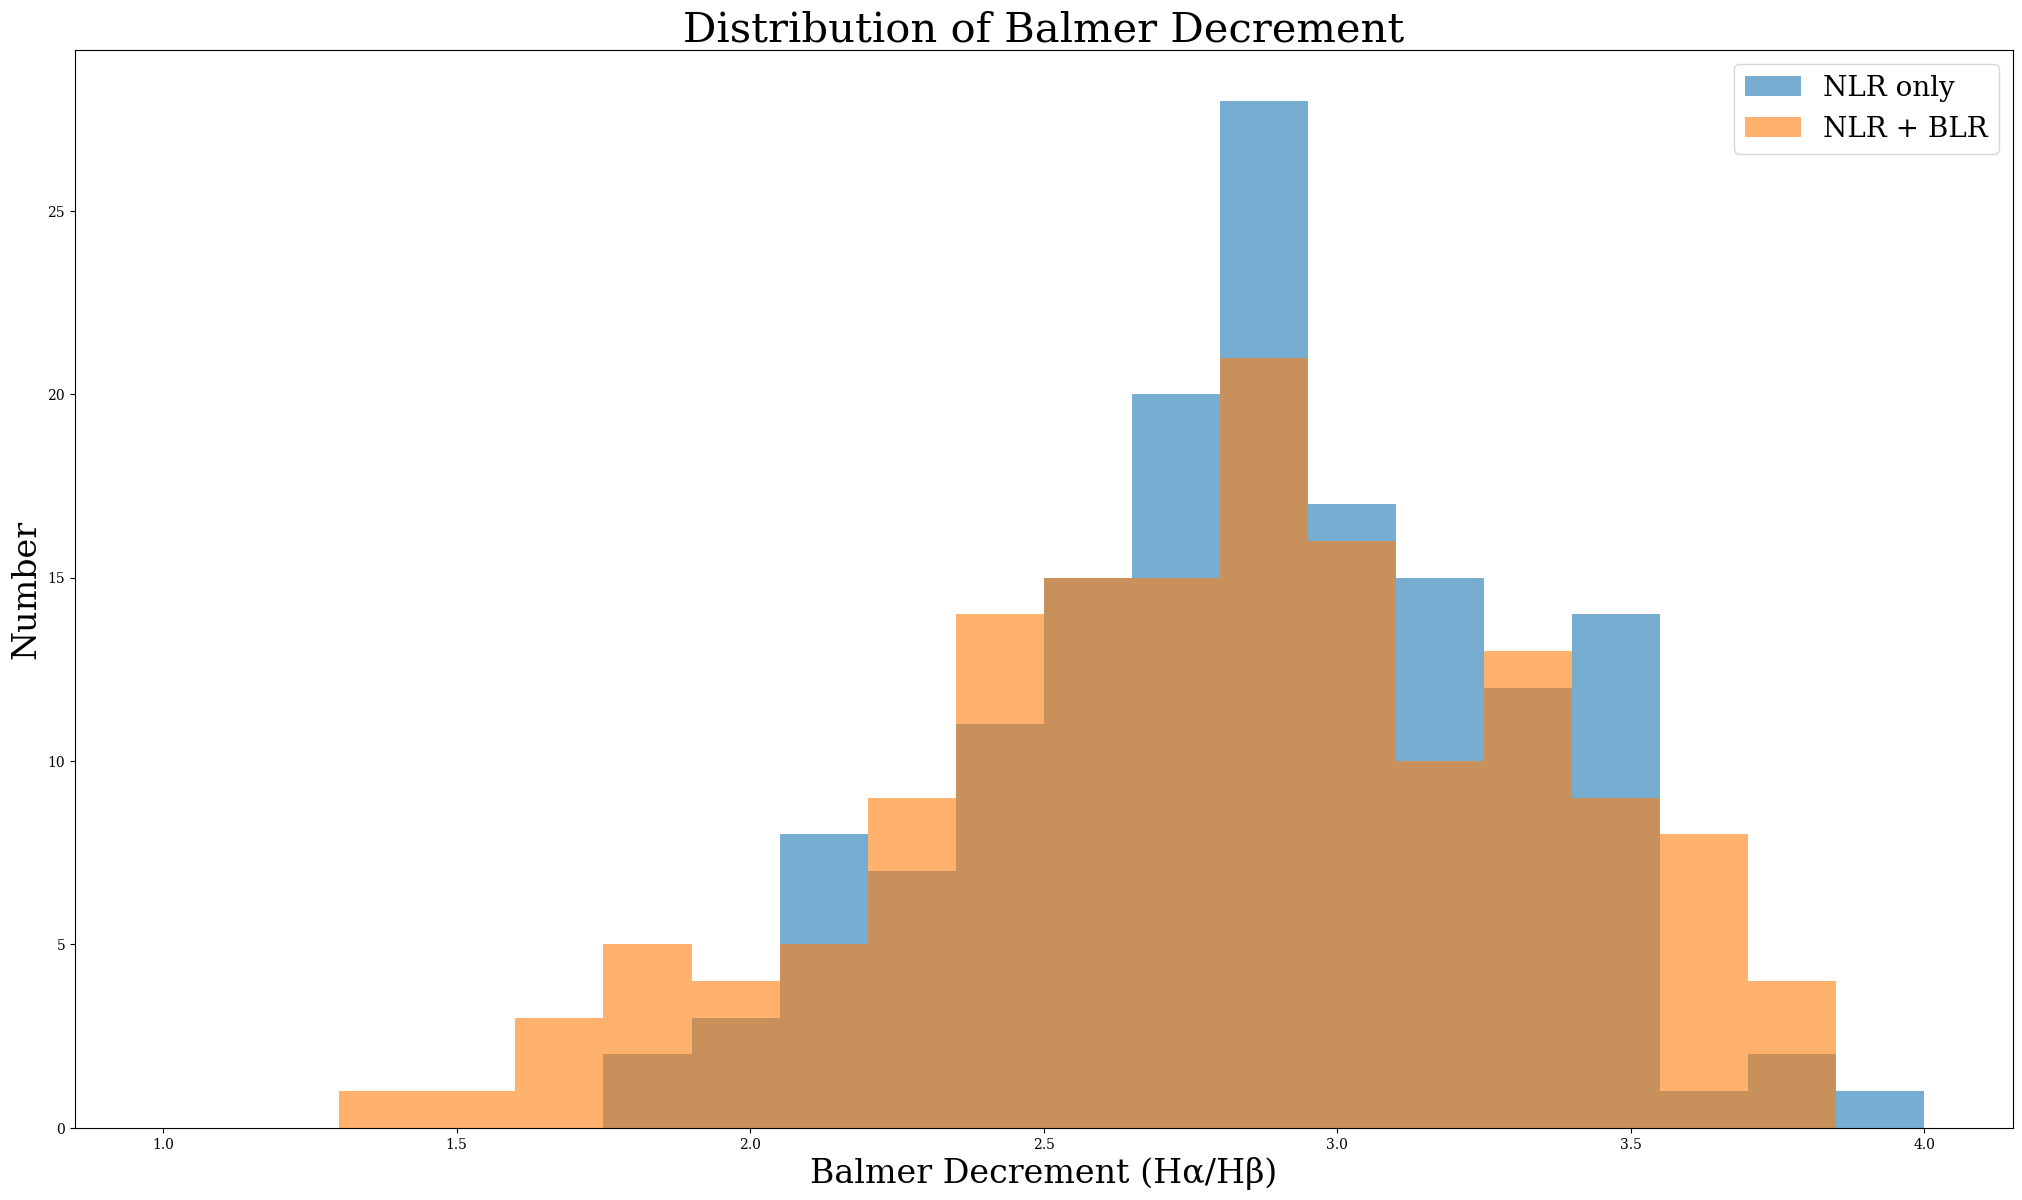

In [51]:
mask=(~np.isinf(alpha_nlr/beta_nlr)&~np.isinf((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr)) )
fig, ax=plt.subplots(figsize=(25,14))
ax.hist((alpha_nlr/beta_nlr)[mask],bins=20,alpha=0.6,range=(1,4),label='NLR only')
ax.hist(((alpha_nlr+alpha_blr)/(beta_nlr+beta_blr))[mask],bins=20,alpha=0.6,range=(1,4),label='NLR + BLR')
ax.set_xlabel('Balmer Decrement (Hα/Hβ)',fontsize=24)
ax.set_ylabel('Number',fontsize=24)
ax.set_title('Distribution of Balmer Decrement',fontsize=30)
ax.legend(fontsize=20)
plt.savefig('./balmer_decrement_distributioncomparison.pdf')

In [39]:
mask.shape

(170,)